### This is a short notebook comparing the two different $(z, \omega)$ methods used to generate Frequency Conversion in waveguides. Here we show that for the proper interaction strength, the *[Generator of Momentum](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.105.013708)* method (valid for arbitrary diserpsion) gives the same qualitative results as the first method which assumes linear dispersion. We consider both unpoled and aperiodically poled cases. This is to showcase that if one can safely work with linear dispersions, one should use the first method functions (much faster).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.fcon import FPulsed_lin, FPulsed_arb
from custom_poling.core.target import Target
from custom_poling.core.custom_crystal import CustomCrystal
from NeedALight.utils import blocks

from NeedALight.fcon import JSD

This section introduces all relevant quantities needed to use the functions and generate the wanted properties.

In [9]:
#Parameters for calculations
N = 301  # Number of frequency values

###########################################
#Parameters for LINEAR dispersion functions
###########################################

Np = 0.0172 # Number of pump photons: Vary this to modify gain values
vp = 0.1  # pump velocity
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread
a = 1.61 / 1.13  # from symmetric grp vel matching

#Ensuring that we are in the symmetric velocity group matching regime.
def symmetric_v(vp, sig, l, a):
    vi = vp / (1 - 2 * a * vp / (l * sig))
    vs = vp / (1 + 2 * a * vp / (l * sig))
    return vs, vi

vs, vi = symmetric_v(vp, sig, l, a)

#Frequency values
wi = -15
wf = 15
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])

#Defining gaussian pump pulse
def pump(x, Np, scale=1):
    return np.sqrt(Np)*np.exp(-((x) ** 2) / (2 * (sig*scale) ** 2)) / np.power(np.pi * (sig*scale)**2, 1 / 4)

#############################################
#Parameters for ARBITRATY dispersion function
#############################################

gamma = 1/(np.sqrt(2 * np.pi * np.abs( vs * vi * vp))) #Int. strength, include all variables needed
ks = w/vs  #signal dispersion
ki = w/vi #idler dispersion
kp_w = (w-w[:,np.newaxis])/vp  #pump dispersion matrix w[:,np.newaxis] is for the signal


####################
# Crystal properties
####################

Ndomain = 1000
dz = l / Ndomain
domain_width = dz
number_domains = Ndomain
L = number_domains * domain_width
k0 = np.pi / domain_width

# Numerical integration parameters for generating domain
k_range = 100/L
dk = k_range/401
k_array = np.arange(k0-k_range/2,k0+k_range/2,dk)

### Unpoled/periodic poling

We begin by considering an unpoled sample. Unlike the linear function, the arbitrary function requires us to specify the vector of spatial points and a corresponding poling domain.

In [10]:
#Spatial grid for arbitrary function
z_list = np.linspace(-l/2,l/2-dz, Ndomain)
domain = np.asarray([1]*len(z_list))

In [11]:
#Initializing pump
pump_Np=lambda x: pump(x, Np) 

#Linear
T_lin, J_lin, Eff_lin, S_lin, Us_lin, Ui_lin, Vs_lin, Vi_lin = FPulsed_lin(vs, vi, vp, pump_Np, [1], l, l, w)

#Arbitrary
T_arb, J_arb, Eff_arb, S_arb, Us_arb, Ui_arb, Vs_arb, Vi_arb = FPulsed_arb(ks, ki, kp_w, gamma, w, z_list, domain, pump_Np)

Comparing the JSDs

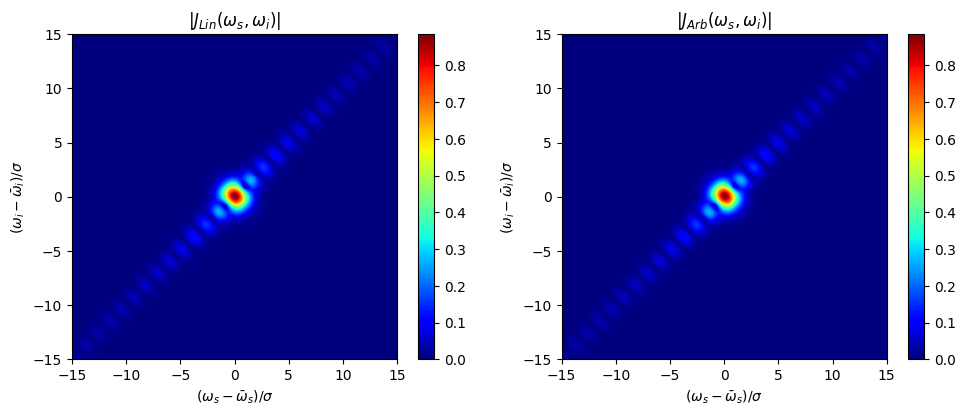

In [12]:
#Generating plot of JSA
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im = axs[0].imshow(np.abs(J_lin), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[0].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[0].set_title(r"$|J_{Lin}(\omega_{s}, \omega_{i})|$" )
plt.colorbar(im, orientation="vertical")

im2 = axs[1].imshow(np.abs(J_arb).T, cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[1].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[1].set_title(r"$|J_{Arb}(\omega_{s}, \omega_{i})|  $" )
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()

Next we plot the Schmidt modes obtained from both methods. We plot the curves on the same figure to show that they are indistinguishable. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin.

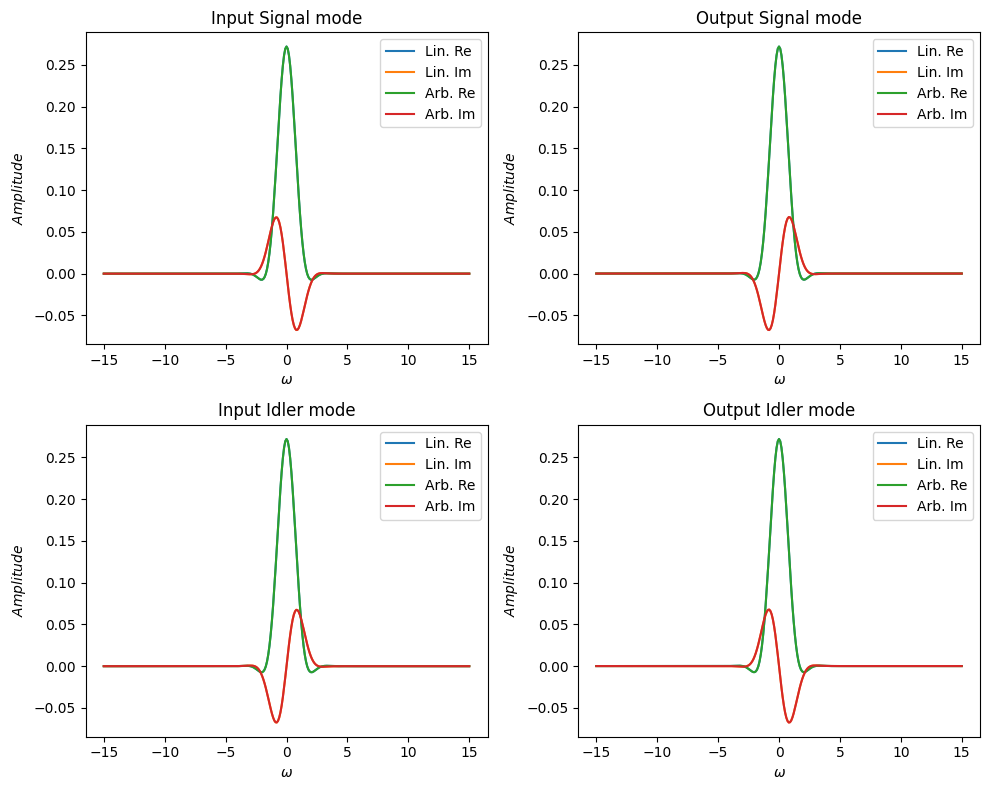

In [13]:
#Looking at the temporal modes
mark=1 #this just takes the first mode of interest. Choose a different value to look at different ones.

fig, ax1 = plt.subplots(2,2, figsize = (10,8))


ax1[0,0].plot(w, np.real(np.exp(-1j*np.angle(Vs_lin[(N-1)//2,-mark]))*Vs_lin[:,-mark]), label='Lin. Re') 
ax1[0,0].plot(w, np.imag(np.exp(-1j*np.angle(Vs_lin[(N-1)//2,-mark]))*Vs_lin[:,-mark]), label='Lin. Im')
ax1[0,0].plot(w, np.real(np.exp(-1j*np.angle(Vs_arb[(N-1)//2,-mark]))*Vs_arb[:,-mark]), label='Arb. Re') 
ax1[0,0].plot(w, np.imag(np.exp(-1j*np.angle(Vs_arb[(N-1)//2,-mark]))*Vs_arb[:,-mark]), label='Arb. Im')
ax1[0,0].set_xlabel(r"$\omega$")
ax1[0,0].set_ylabel(r"$Amplitude$")
ax1[0,0].set_title('Input Signal mode')
ax1[0,0].legend()

ax1[0,1].plot(w, np.real(np.exp(-1j*np.angle(Us_lin[(N-1)//2,-mark]))*Us_lin[:,-mark]), label='Lin. Re') 
ax1[0,1].plot(w, np.imag(np.exp(-1j*np.angle(Us_lin[(N-1)//2,-mark]))*Us_lin[:,-mark]), label='Lin. Im')
ax1[0,1].plot(w, np.real(np.exp(-1j*np.angle(Us_arb[(N-1)//2,-mark]))*Us_arb[:,-mark]), label='Arb. Re') 
ax1[0,1].plot(w, np.imag(np.exp(-1j*np.angle(Us_arb[(N-1)//2,-mark]))*Us_arb[:,-mark]), label='Arb. Im')
ax1[0,1].set_xlabel(r"$\omega$")
ax1[0,1].set_ylabel(r"$Amplitude$")
ax1[0,1].set_title('Output Signal mode')
ax1[0,1].legend()

ax1[1,0].plot(w, np.real(np.exp(-1j*np.angle(Vi_lin[(N-1)//2,-mark]))*Vi_lin[:,-mark]), label='Lin. Re') 
ax1[1,0].plot(w, np.imag(np.exp(-1j*np.angle(Vi_lin[(N-1)//2,-mark]))*Vi_lin[:,-mark]), label='Lin. Im')
ax1[1,0].plot(w, np.real(np.exp(-1j*np.angle(Vi_arb[(N-1)//2,-mark]))*Vi_arb[:,-mark]), label='Arb. Re') 
ax1[1,0].plot(w, np.imag(np.exp(-1j*np.angle(Vi_arb[(N-1)//2,-mark]))*Vi_arb[:,-mark]), label='Arb. Im')
ax1[1,0].set_xlabel(r"$\omega$")
ax1[1,0].set_ylabel(r"$Amplitude$")
ax1[1,0].set_title('Input Idler mode')
ax1[1,0].legend()

ax1[1,1].plot(w, np.real(np.exp(-1j*np.angle(Ui_lin[(N-1)//2,-mark]))*Ui_lin[:,-mark]), label='Lin. Re') 
ax1[1,1].plot(w, np.imag(np.exp(-1j*np.angle(Ui_lin[(N-1)//2,-mark]))*Ui_lin[:,-mark]), label='Lin. Im')
ax1[1,1].plot(w, np.real(np.exp(-1j*np.angle(Ui_arb[(N-1)//2,-mark]))*Ui_arb[:,-mark]), label='Arb. Re') 
ax1[1,1].plot(w, np.imag(np.exp(-1j*np.angle(Ui_arb[(N-1)//2,-mark]))*Ui_arb[:,-mark]), label='Arb. Im')
ax1[1,1].set_xlabel(r"$\omega$")
ax1[1,1].set_ylabel(r"$Amplitude$")
ax1[1,1].set_title('Output Idler mode')
ax1[1,1].legend()


fig.tight_layout()
plt.show()

Next we print out certain values to compare both methods.

In [14]:
print('Selectivity Numbers')
print(' Lin. method: %f' %S_lin)
print(" Arb. method: %f" %S_arb)

print('Conversion Efficiency')
print(' Lin. method: %f' %Eff_lin[-mark])
print(' Arb. method: %f' %Eff_arb[-mark])

print('Max absolute JSD value')
print(' Lin. method: %f' %np.amax(np.abs(J_lin)))
print(' Arb. method: %f' %np.amax(np.abs(J_arb)))

print('Signal input mode overlap: %f' %np.abs(np.vdot(Vs_lin[:,-mark],Vs_arb[:,-mark]))**2)
print('Signal ouput mode overlap: %f' %np.abs(np.vdot(Us_lin[:,-mark],Us_arb[:,-mark]))**2)
print('Idler input mode overlap: %f' %np.abs(np.vdot(Vi_lin[:,-mark],Vi_arb[:,-mark]))**2)
print('Idler ouput mode overlap: %f' %np.abs(np.vdot(Ui_lin[:,-mark],Ui_arb[:,-mark]))**2)

Selectivity Numbers
 Lin. method: 0.522759
 Arb. method: 0.522750
Conversion Efficiency
 Lin. method: 0.904169
 Arb. method: 0.904169
Max absolute JSD value
 Lin. method: 0.884864
 Arb. method: 0.884864
Signal input mode overlap: 0.999999
Signal ouput mode overlap: 0.999999
Idler input mode overlap: 0.999999
Idler ouput mode overlap: 0.999999


For the parameters chosen, we see that we have good agreement numerically and qualitatively. However, it might be the case that some parameters lead to some discrepancies in numerical values due to the trotterization used in the arbitrary function.

### Aperiodic Poling

We now consider aperiodic poling. We generate the crystal domain which produces a gaussian phase-matching function. We use the code and follow the examples of [Custom-Poling](https://github.com/abranczyk/custom-poling). We also redefine the pumps for both methods.

In [15]:
# Create a custom crystal object
custom_crystal_gauss = CustomCrystal(domain_width,number_domains)
domain_middles_gauss = custom_crystal_gauss.domain_middles

#Define and plot the target function
std = 10
height = 0.025
target_pmf_gauss = lambda k:1j*height*np.exp(-(k-k0)**2/(2*std**2))*np.exp(1j * L/2 * k)
target_gauss = Target(target_pmf_gauss,k_array)

# Compute and plot the target amplitude
target_amplitude_gauss = target_gauss.compute_amplitude(k0,domain_middles_gauss)

# Compute and plot the custom domains
custom_domains_gauss = custom_crystal_gauss.compute_domains(target_amplitude_gauss,k0)

#Shifting the domain such that we are at 0 central frequency
if len(custom_domains_gauss)==Ndomain:
    domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)) 
else:
    domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)+[1]) 


#Proper scale factor so that Gaussian PMF and Gaussian Pump have the same width
sc=std/(2*a)

#Scaled pump envelopes
Np_s = 2.2

#Initializing pump
pump_Np_s=lambda x: pump(x, Np_s*np.sqrt(sc), scale=sc)

In [ ]:
#Linear
T_lin_s, J_lin_s, Eff_lin_s, S_lin_s, Us_lin_s, Ui_lin_s, Vs_lin_s, Vi_lin_s = FPulsed_lin(vs, vi, vp, pump_Np_s, domain, dz, l, w)

#Arbitrary
T_arb_s, J_arb_s, Eff_arb_s, S_arb_s, Us_arb_s, Ui_arb_s, Vs_arb_s, Vi_arb_s = FPulsed_arb(ks, ki, kp_w, gamma, w, z_list, domain, pump_Np_s)

Comparing the JSDs

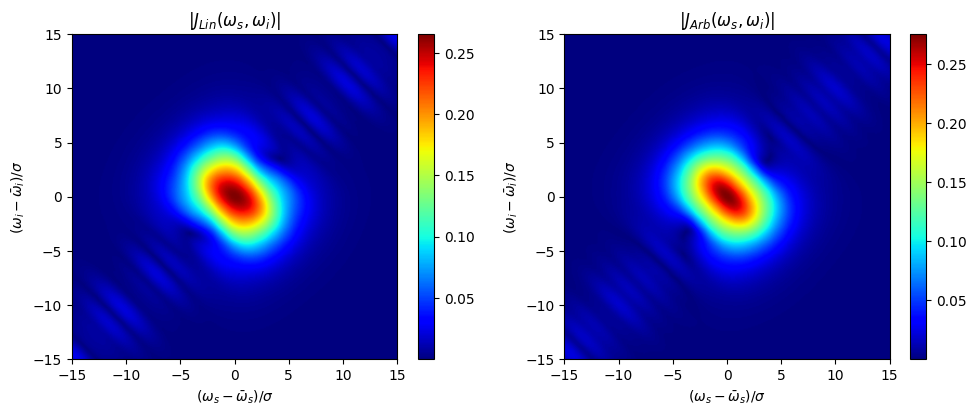

In [22]:
#Generating plot of JSA
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im = axs[0].imshow(np.abs(J_lin_s), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[0].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[0].set_title(r"$|J_{Lin}(\omega_{s}, \omega_{i})|$" )
plt.colorbar(im, orientation="vertical")

im2 = axs[1].imshow(np.abs(J_arb_s).T, cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[1].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[1].set_title(r"$|J_{Arb}(\omega_{s}, \omega_{i})|  $" )
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()

Next we plot the Schmidt modes obtained from both methods. We plot the curves on the same figure to show that they are indistinguishable. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin.

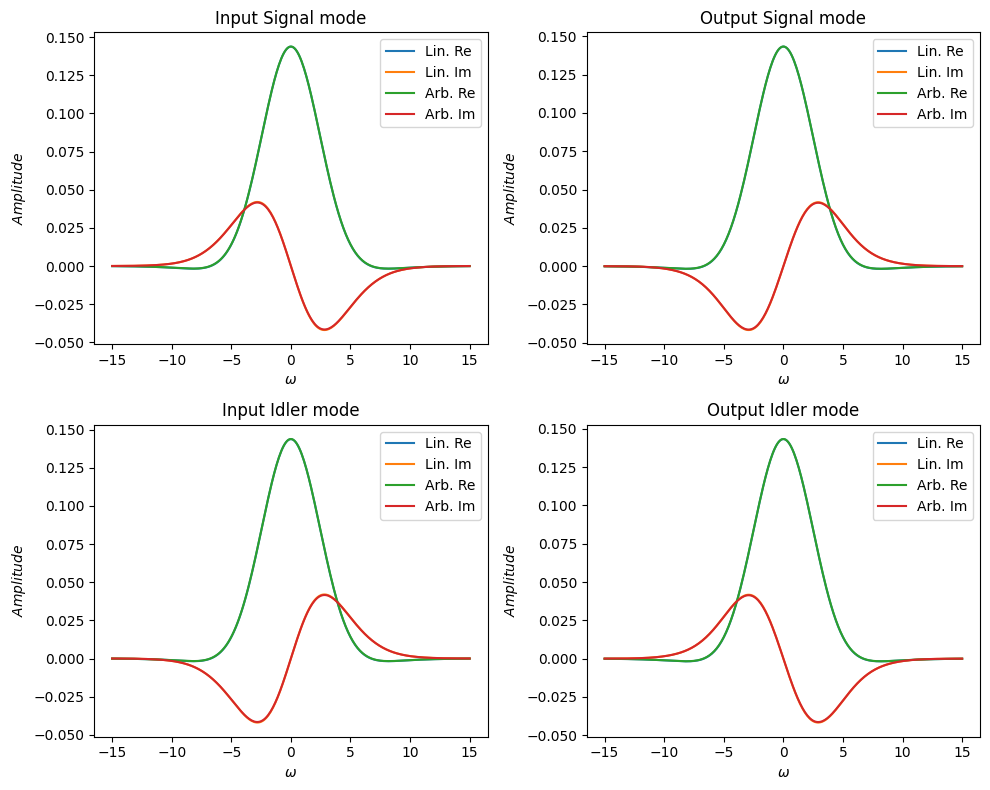

In [23]:
#Looking at the temporal modes
mark=1 #this just takes the first mode of interest. Choose a different value to look at different ones.

fig, ax1 = plt.subplots(2,2, figsize = (10,8))


ax1[0,0].plot(w, np.real(np.exp(-1j*np.angle(Vs_lin_s[(N-1)//2,-mark]))*Vs_lin_s[:,-mark]), label='Lin. Re') 
ax1[0,0].plot(w, np.imag(np.exp(-1j*np.angle(Vs_lin_s[(N-1)//2,-mark]))*Vs_lin_s[:,-mark]), label='Lin. Im')
ax1[0,0].plot(w, np.real(np.exp(-1j*np.angle(Vs_arb_s[(N-1)//2,-mark]))*Vs_arb_s[:,-mark]), label='Arb. Re') 
ax1[0,0].plot(w, np.imag(np.exp(-1j*np.angle(Vs_arb_s[(N-1)//2,-mark]))*Vs_arb_s[:,-mark]), label='Arb. Im')
ax1[0,0].set_xlabel(r"$\omega$")
ax1[0,0].set_ylabel(r"$Amplitude$")
ax1[0,0].set_title('Input Signal mode')
ax1[0,0].legend()

ax1[0,1].plot(w, np.real(np.exp(-1j*np.angle(Us_lin_s[(N-1)//2,-mark]))*Us_lin_s[:,-mark]), label='Lin. Re') 
ax1[0,1].plot(w, np.imag(np.exp(-1j*np.angle(Us_lin_s[(N-1)//2,-mark]))*Us_lin_s[:,-mark]), label='Lin. Im')
ax1[0,1].plot(w, np.real(np.exp(-1j*np.angle(Us_arb_s[(N-1)//2,-mark]))*Us_arb_s[:,-mark]), label='Arb. Re') 
ax1[0,1].plot(w, np.imag(np.exp(-1j*np.angle(Us_arb_s[(N-1)//2,-mark]))*Us_arb_s[:,-mark]), label='Arb. Im')
ax1[0,1].set_xlabel(r"$\omega$")
ax1[0,1].set_ylabel(r"$Amplitude$")
ax1[0,1].set_title('Output Signal mode')
ax1[0,1].legend()

ax1[1,0].plot(w, np.real(np.exp(-1j*np.angle(Vi_lin_s[(N-1)//2,-mark]))*Vi_lin_s[:,-mark]), label='Lin. Re') 
ax1[1,0].plot(w, np.imag(np.exp(-1j*np.angle(Vi_lin_s[(N-1)//2,-mark]))*Vi_lin_s[:,-mark]), label='Lin. Im')
ax1[1,0].plot(w, np.real(np.exp(-1j*np.angle(Vi_arb_s[(N-1)//2,-mark]))*Vi_arb_s[:,-mark]), label='Arb. Re') 
ax1[1,0].plot(w, np.imag(np.exp(-1j*np.angle(Vi_arb_s[(N-1)//2,-mark]))*Vi_arb_s[:,-mark]), label='Arb. Im')
ax1[1,0].set_xlabel(r"$\omega$")
ax1[1,0].set_ylabel(r"$Amplitude$")
ax1[1,0].set_title('Input Idler mode')
ax1[1,0].legend()

ax1[1,1].plot(w, np.real(np.exp(-1j*np.angle(Ui_lin_s[(N-1)//2,-mark]))*Ui_lin_s[:,-mark]), label='Lin. Re') 
ax1[1,1].plot(w, np.imag(np.exp(-1j*np.angle(Ui_lin_s[(N-1)//2,-mark]))*Ui_lin_s[:,-mark]), label='Lin. Im')
ax1[1,1].plot(w, np.real(np.exp(-1j*np.angle(Ui_arb_s[(N-1)//2,-mark]))*Ui_arb_s[:,-mark]), label='Arb. Re') 
ax1[1,1].plot(w, np.imag(np.exp(-1j*np.angle(Ui_arb_s[(N-1)//2,-mark]))*Ui_arb_s[:,-mark]), label='Arb. Im')
ax1[1,1].set_xlabel(r"$\omega$")
ax1[1,1].set_ylabel(r"$Amplitude$")
ax1[1,1].set_title('Output Idler mode')
ax1[1,1].legend()


fig.tight_layout()
plt.show()

Next we print out certain values to compare both methods.

In [24]:
print('Selectivity Numbers')
print(' Lin. method: %f' %S_lin_s)
print(" Arb. method: %f" %S_arb_s)

print('Conversion Efficiency')
print(' Lin. method: %f' %Eff_lin_s[-mark])
print(' Arb. method: %f' %Eff_arb_s[-mark])

print('Max absolute JSD value')
print(' Lin. method: %f' %np.amax(np.abs(J_lin_s)))
print(' Arb. method: %f' %np.amax(np.abs(J_arb_s)))

print('Signal input mode overlap: %f' %np.abs(np.vdot(Vs_lin_s[:,-mark],Vs_arb_s[:,-mark]))**2)
print('Signal ouput mode overlap: %f' %np.abs(np.vdot(Us_lin_s[:,-mark],Us_arb_s[:,-mark]))**2)
print('Idler input mode overlap: %f' %np.abs(np.vdot(Vi_lin_s[:,-mark],Vi_arb_s[:,-mark]))**2)
print('Idler ouput mode overlap: %f' %np.abs(np.vdot(Ui_lin_s[:,-mark],Ui_arb_s[:,-mark]))**2)

Selectivity Numbers
 Lin. method: 0.765504
 Arb. method: 0.764044
Conversion Efficiency
 Lin. method: 0.937059
 Arb. method: 0.937385
Max absolute JSD value
 Lin. method: 0.265293
 Arb. method: 0.275116
Signal input mode overlap: 0.999990
Signal ouput mode overlap: 0.999990
Idler input mode overlap: 0.999990
Idler ouput mode overlap: 0.999990


For aperiodic poling we see good qualitative agreement between both methods. However, for the same spatial grid, the numerical discrepancies are bigger than in the unpoled case. 